# 05 — XGBRanker with Walk-Forward Cross-Validation

**Changes vs original:**

- Replaced the single train/valid/test split with **expanding-window walk-forward CV**.
  Each fold trains on all data up to the fold start, then tests on the next 6 months.
  The model is re-trained from scratch every fold.
- A **1-month gap** is inserted between training end and test start to prevent any
  leakage from the lagged monthly return construction at the boundary.
- IC and long-short returns are accumulated across all test folds and evaluated together,
  giving a valid out-of-sample estimate across all available test periods.

**Fold structure (60 months total, 2017-01 to 2021-12):**

| Fold | Train through | Gap | Test period |
|------|--------------|-----|-------------|
| 0    | 2019-12      | 1m  | 2020-02 → 2020-07 |
| 1    | 2020-06      | 1m  | 2020-08 → 2021-01 |
| 2    | 2020-12      | 1m  | 2021-02 → 2021-07 |
| 3    | 2021-06      | 1m  | 2021-08 → 2021-12 |

In [57]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta
from scipy.stats import spearmanr
from xgboost import XGBRanker


## 1. Load data

In [58]:
monthly = pd.read_csv(
    r"C:\Users\naksh\Projects\xgboost_stock_ranking\data\model_data.csv",
    parse_dates=["Date"]
)

with open(r"C:\Users\naksh\Projects\xgboost_stock_ranking\data\processed\feature_cols.json") as f:
    feature_cols = json.load(f)

monthly = monthly.sort_values(["Date", "SecuritiesCode"]).reset_index(drop=True)

print("Shape:", monthly.shape, "  Features:", len(feature_cols))
print("Date range:", monthly["Date"].min().date(), "→", monthly["Date"].max().date())

Shape: (114554, 75)   Features: 64
Date range: 2017-01-31 → 2021-11-30


## 2. Ordinal rank target (32 buckets per month)

In [59]:
monthly["rank_target"] = (
    monthly.groupby("Date")["target_1m"]
    .transform(
        lambda x: pd.qcut(x.rank(method="first"), q=32, labels=False)
    )
    .astype(int)
)

## 3. Walk-forward fold definitions

In [60]:
# Minimum training window before the first fold
MIN_TRAIN_MONTHS = 36
# Number of months in each test fold
TEST_FOLD_MONTHS = 6
# Gap between training end and test start (months)
GAP_MONTHS = 1

all_months = sorted(monthly["Date"].dt.to_period("M").unique())

folds = []
fold_start_idx = MIN_TRAIN_MONTHS  # first test fold starts after MIN_TRAIN_MONTHS

while fold_start_idx + GAP_MONTHS < len(all_months):
    train_end_period = all_months[fold_start_idx - 1]          # last training month
    test_start_period = all_months[fold_start_idx + GAP_MONTHS]  # after gap
    test_end_idx = min(fold_start_idx + GAP_MONTHS + TEST_FOLD_MONTHS - 1, len(all_months) - 1)
    test_end_period = all_months[test_end_idx]

    folds.append({
        "train_end":   train_end_period.to_timestamp(how="end"),
        "test_start":  test_start_period.to_timestamp(how="start"),
        "test_end":    test_end_period.to_timestamp(how="end"),
    })

    fold_start_idx += TEST_FOLD_MONTHS  # advance by one test fold

print(f"{len(folds)} folds:")
for i, f in enumerate(folds):
    print(f"  Fold {i}: train ≤ {f['train_end'].date()}  |  "
          f"test {f['test_start'].date()} → {f['test_end'].date()}")

4 folds:
  Fold 0: train ≤ 2019-12-31  |  test 2020-02-01 → 2020-07-31
  Fold 1: train ≤ 2020-06-30  |  test 2020-08-01 → 2021-01-31
  Fold 2: train ≤ 2020-12-31  |  test 2021-02-01 → 2021-07-31
  Fold 3: train ≤ 2021-06-30  |  test 2021-08-01 → 2021-11-30


## 4. Walk-forward training loop

In [61]:
target_col = "rank_target"

all_test_predictions = []   # list of DataFrames, one per fold
trained_models = []
for fold_idx, fold in enumerate(folds):

    train_df = monthly[monthly["Date"] <= fold["train_end"]].copy()
    test_df  = monthly[
        (monthly["Date"] >= fold["test_start"]) &
        (monthly["Date"] <= fold["test_end"])
    ].copy()

    if len(train_df) == 0 or len(test_df) == 0:
        continue

    # Use the last 6 months of training as internal validation for early stopping
    val_cutoff = train_df["Date"].max() - pd.DateOffset(months=6)
    inner_train = train_df[train_df["Date"] <= val_cutoff]
    inner_valid = train_df[train_df["Date"] >  val_cutoff]

    X_tr, y_tr = inner_train[feature_cols], inner_train[target_col]
    X_va, y_va = inner_valid[feature_cols], inner_valid[target_col]
    X_te       = test_df[feature_cols]

    group_tr = inner_train.groupby("Date").size().to_list()
    group_va = inner_valid.groupby("Date").size().to_list()

    ranker = XGBRanker(
        objective="rank:pairwise",
        eval_metric="ndcg",
        learning_rate=0.05,
        n_estimators=1000,
        max_depth=6,
        min_child_weight=30,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        early_stopping_rounds=50,
        random_state=42,
    )

    ranker.fit(
        X_tr, y_tr,
        group=group_tr,
        eval_set=[(X_tr, y_tr), (X_va, y_va)],
        eval_group=[group_tr, group_va],
        verbose=False,
    )
    trained_models.append(ranker)

    test_df = test_df.copy()
    test_df["score"] = ranker.predict(X_te)
    test_df["fold"]  = fold_idx

    test_df = test_df.copy()

    test_df["score"] = ranker.predict(X_te)
    test_df["fold"] = fold_idx

    all_test_predictions.append(test_df)

    # Per-fold IC summary
    fold_ic = (
        test_df.groupby("Date")
               .apply(lambda x: spearmanr(x["score"], x["target_1m"]).correlation,
                      include_groups=False)
    )
    print(f"Fold {fold_idx}: best_iter={ranker.best_iteration}  "
          f"mean_IC={fold_ic.mean():.4f}  IC>0={( fold_ic > 0).mean():.0%}")

oos = pd.concat(all_test_predictions, ignore_index=True)
print(f"\nTotal OOS rows: {len(oos):,}")

Fold 0: best_iter=42  mean_IC=0.0676  IC>0=67%
Fold 1: best_iter=97  mean_IC=0.0072  IC>0=50%
Fold 2: best_iter=29  mean_IC=0.0289  IC>0=50%
Fold 3: best_iter=20  mean_IC=-0.0199  IC>0=75%

Total OOS rows: 43,791


## 5. Aggregate OOS evaluation

In [62]:
monthly_ic = (
    oos.groupby("Date")
       .apply(lambda x: spearmanr(x["score"], x["target_1m"]).correlation,
              include_groups=False)
)

icir = monthly_ic.mean() / (monthly_ic.std() + 1e-8)

print("=== OOS IC Summary (all folds combined) ===")
print(monthly_ic.describe())
print(f"\nMean IC  : {monthly_ic.mean():.4f}")
print(f"ICIR     : {icir:.4f}")
print(f"IC > 0   : {(monthly_ic > 0).mean():.2%}")

=== OOS IC Summary (all folds combined) ===
count    22.000000
mean      0.024677
std       0.076050
min      -0.162647
25%      -0.020485
50%       0.016206
75%       0.078813
max       0.191844
dtype: float64

Mean IC  : 0.0247
ICIR     : 0.3245
IC > 0   : 59.09%


## 6. Long-short portfolio backtest

In [63]:
def long_short_return(df):
    df = df.sort_values("score")
    n  = max(1, int(len(df) * 0.10))
    return df.iloc[-n:]["target_1m"].mean() - df.iloc[:n]["target_1m"].mean()

portfolio = oos.groupby("Date").apply(long_short_return, include_groups=False)

print(portfolio.describe())
print(f"\nAverage monthly L/S return : {portfolio.mean():.4%}")
print(f"Annualised Sharpe (approx) : {portfolio.mean() / portfolio.std() * np.sqrt(12):.2f}")

count    22.000000
mean      0.013226
std       0.026109
min      -0.024637
25%      -0.006094
50%       0.011351
75%       0.021461
max       0.090530
dtype: float64

Average monthly L/S return : 1.3226%
Annualised Sharpe (approx) : 1.75


## 7. Equity curve

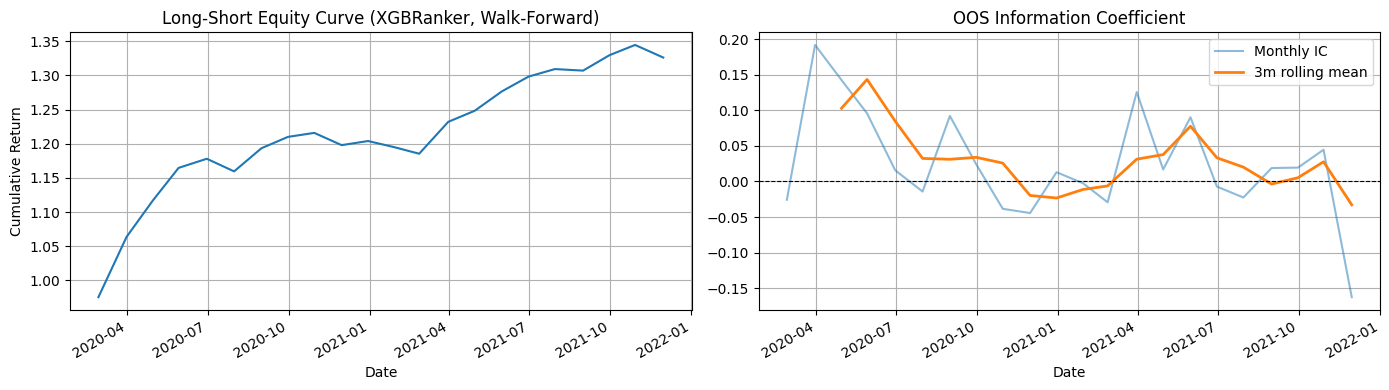

In [64]:
equity = (1 + portfolio).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

equity.plot(ax=axes[0], title="Long-Short Equity Curve (XGBRanker, Walk-Forward)")
axes[0].set_ylabel("Cumulative Return")
axes[0].grid(True)

monthly_ic.plot(ax=axes[1], alpha=0.5, label="Monthly IC")
monthly_ic.rolling(3).mean().plot(ax=axes[1], label="3m rolling mean", linewidth=2)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("OOS Information Coefficient")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

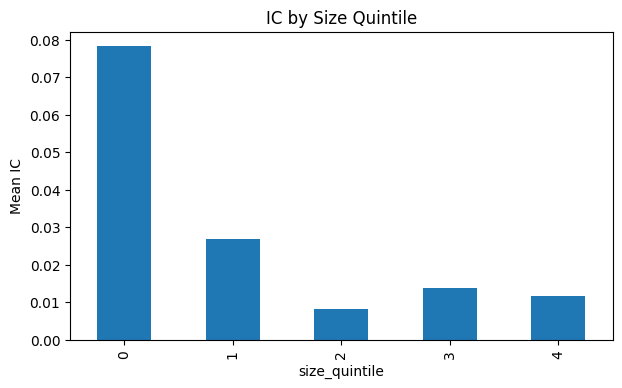

size_quintile
0    0.078171
1    0.026781
2    0.008274
3    0.013670
4    0.011680
dtype: float64


In [65]:
from scipy.stats import spearmanr

tmp = oos.copy()

tmp["size_quintile"] = (
    tmp.groupby("Date")["avg_dollar_vol_1m"]
       .transform(
           lambda x: pd.qcut(
               x.rank(method="first"),
               5,
               labels=False,
               duplicates="drop"
           )
       )
)

ic_size = (
    tmp.groupby(["Date", "size_quintile"])
       .apply(
           lambda x: spearmanr(
               x["score"],
               x["target_1m"]
           ).correlation,
           include_groups=False
       )
       .groupby(level=1)
       .mean()
)

ic_size.plot.bar(figsize=(7,4))
plt.ylabel("Mean IC")
plt.title("IC by Size Quintile")
plt.show()

print(ic_size)

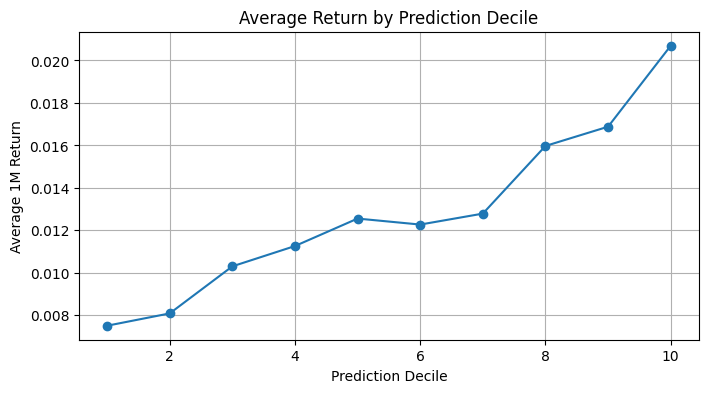

decile
0    0.007512
1    0.008092
2    0.010307
3    0.011263
4    0.012556
5    0.012274
6    0.012790
7    0.015975
8    0.016882
9    0.020693
Name: target_1m, dtype: float64


In [66]:
tmp = oos.copy()

tmp["decile"] = (
    tmp.groupby("Date")["score"]
       .transform(lambda x: pd.qcut(
           x.rank(method="first"),
           10,
           labels=False,
           duplicates="drop"
       ))
)

decile_returns = (
    tmp.groupby("decile")["target_1m"]
       .mean()
)

plt.figure(figsize=(8,4))

plt.plot(
    decile_returns.index + 1,
    decile_returns.values,
    marker="o"
)

plt.grid(True)

plt.xlabel("Prediction Decile")
plt.ylabel("Average 1M Return")
plt.title("Average Return by Prediction Decile")

plt.show()

print(decile_returns)

In [67]:
top = (
    oos.groupby("Date")
       .apply(
           lambda x: x.nlargest(
               max(1,int(len(x)*0.1)),
               "score"
           ),
           include_groups=False
       )
)

bottom = (
    oos.groupby("Date")
       .apply(
           lambda x: x.nsmallest(
               max(1,int(len(x)*0.1)),
               "score"
           ),
           include_groups=False
       )
)

comparison = pd.DataFrame({

    "Top": top[feature_cols].mean(),

    "Bottom": bottom[feature_cols].mean()

})

comparison["Difference"] = (
    comparison["Top"] -
    comparison["Bottom"]
)

comparison = comparison.reindex(

    comparison["Difference"]
    .abs()
    .sort_values(ascending=False)
    .index

)

comparison.head(30)

,Top,Bottom,Difference
ForecastOperatingProfit_upgrade,0.983228,-0.508741,1.491970
ForecastNetSales_revision,0.915483,-0.516663,1.432146
ForecastOrdinaryProfit_upgrade,0.962698,-0.440193,1.402890
ForecastNetSales_upgrade,0.759219,-0.595057,1.354276
ForecastOrdinaryProfit_revision,0.883423,-0.453232,1.336655
ForecastOperatingProfit_revision,0.896277,-0.426120,1.322397
ForecastProfit_upgrade,0.886414,-0.432220,1.318634
Equity,-0.581360,0.535366,-1.116726
ForecastEarningsPerShare_upgrade,0.755903,-0.315013,1.070916
ForecastProfit_revision,0.729645,-0.338582,1.068227


C:\Users\naksh\AppData\Local\Temp\ipykernel_10692\1418432314.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearmanr(


Top Positive Factors
vol_12m                              0.026647
max_return_3m                        0.011758
ForecastOrdinaryProfit_upgrade       0.010080
vol_6m                               0.008989
earnings_yield                       0.008977
vol_3m                               0.008335
ForecastEarningsPerShare_upgrade     0.007195
forecast_roe                         0.006775
forecast_roa                         0.006740
TotalAssets_yoy                      0.006739
ForecastNetSales_upgrade             0.006489
ForecastProfit_upgrade               0.006308
ForecastOrdinaryProfit_revision      0.005620
ForecastEarningsPerShare_revision    0.005325
ForecastOperatingProfit_upgrade      0.004585
forecast_operating_margin            0.004432
Equity_yoy                           0.004060
ForecastNetSales_revision            0.003425
ForecastProfit_revision              0.002906
mom_6m                               0.002590
dtype: float64

Top Negative Factors
ma_3m_ratio         -0

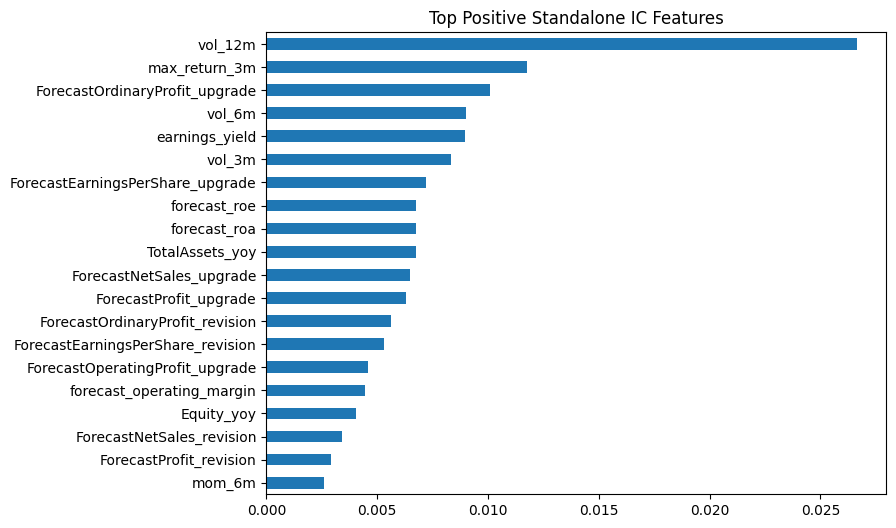

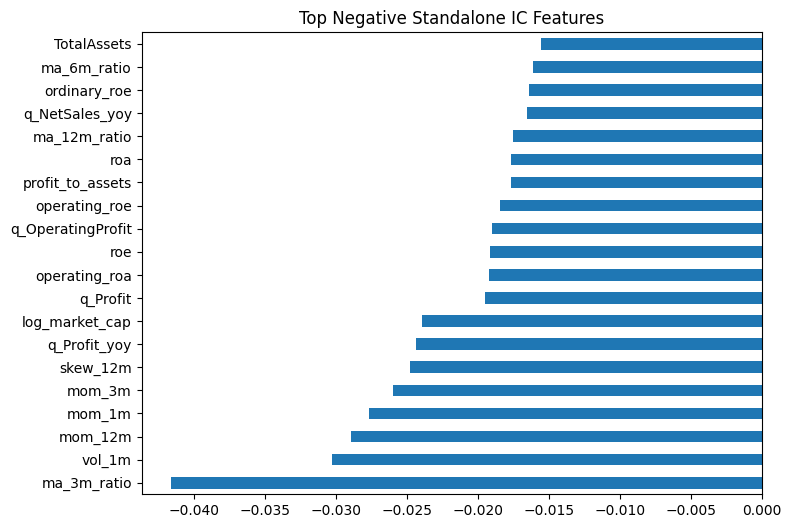

In [68]:
from scipy.stats import spearmanr

feature_ic = {}

for feature in feature_cols:

    ic = (
        oos.groupby("Date")
           .apply(
               lambda x:
               spearmanr(
                   x[feature],
                   x["target_1m"]
               ).correlation,
               include_groups=False
           )
    )

    feature_ic[feature] = ic.mean()

feature_ic = pd.Series(feature_ic)

print("Top Positive Factors")
print(feature_ic.sort_values(ascending=False).head(20))

print("\nTop Negative Factors")
print(feature_ic.sort_values().head(20))

plt.figure(figsize=(8,6))
feature_ic.sort_values(ascending=False).head(20).sort_values().plot.barh()
plt.title("Top Positive Standalone IC Features")
plt.show()

plt.figure(figsize=(8,6))
feature_ic.sort_values().head(20).plot.barh()
plt.title("Top Negative Standalone IC Features")
plt.show()

In [69]:
from scipy.stats import spearmanr

tmp = oos.copy()

tmp["size_quintile"] = (
    tmp.groupby("Date")["avg_dollar_vol_1m"]
       .transform(
           lambda x: pd.qcut(
               x.rank(method="first"),
               5,
               labels=False,
               duplicates="drop"
           )
       )
)

In [70]:
results = []

for feature in feature_cols:

    for q in range(5):

        subset = tmp[tmp["size_quintile"] == q]

        ic = (
            subset.groupby("Date")
                  .apply(
                      lambda x: spearmanr(
                          x[feature],
                          x["target_1m"]
                      ).correlation,
                      include_groups=False
                  )
        )

        results.append({

            "Feature": feature,
            "Quintile": q,
            "Mean IC": ic.mean()

        })

feature_ic_size = pd.DataFrame(results)

C:\Users\naksh\AppData\Local\Temp\ipykernel_10692\1796347310.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  lambda x: spearmanr(


In [71]:
pivot = feature_ic_size.pivot(
    index="Feature",
    columns="Quintile",
    values="Mean IC"
)

pivot.columns = [
    "Small",
    "Q2",
    "Q3",
    "Q4",
    "Large"
]

pivot.head()

,Small,Q2,Q3,Q4,Large
Feature,,,,,
AdjustmentFactor,NaN,NaN,NaN,NaN,NaN
EarningsPerShare,-0.004089,-0.006916,-0.005798,-0.001053,0.024305
Equity,-0.048578,-0.021570,-0.008522,0.001996,-0.000711
Equity_yoy,0.015837,0.012066,0.000599,-0.000660,-0.001925
ForecastEarningsPerShare_revision,0.031001,0.018375,-0.012671,-0.003615,0.013065


In [72]:
pivot.sort_values(
    "Small",
    ascending=False
).head(25)

,Small,Q2,Q3,Q4,Large
Feature,,,,,
vol_12m,0.044938,-0.011234,0.033419,0.016220,0.083887
ForecastEarningsPerShare_upgrade,0.035006,0.016758,-0.014055,-0.010326,0.016236
vol_6m,0.032724,0.000735,0.020893,0.003439,0.027927
ForecastProfit_revision,0.032386,0.015698,-0.010384,-0.006750,0.010078
ForecastProfit_upgrade,0.032222,0.010291,-0.012591,-0.014697,0.012727
ForecastEarningsPerShare_revision,0.031001,0.018375,-0.012671,-0.003615,0.013065
vol_3m,0.027610,0.008735,0.026465,-0.001321,0.017666
ForecastOrdinaryProfit_upgrade,0.025818,0.013779,-0.002175,-0.008543,0.011304
forecast_roe,0.022474,0.008088,-0.003522,0.004098,0.012224


In [73]:
pivot.sort_values(
    "Large",
    ascending=False
).head(25)

,Small,Q2,Q3,Q4,Large
Feature,,,,,
vol_12m,0.044938,-0.011234,0.033419,0.016220,0.083887
equity_ratio,-0.012157,0.015090,-0.011179,-0.006467,0.029954
vol_6m,0.032724,0.000735,0.020893,0.003439,0.027927
forecast_roa,0.009856,0.014304,-0.009654,0.002356,0.024538
EarningsPerShare,-0.004089,-0.006916,-0.005798,-0.001053,0.024305
max_return_3m,0.018222,0.013432,0.022393,0.003735,0.023289
forecast_profit_margin,-0.007829,0.000293,-0.014190,0.004958,0.022729
avg_dollar_vol_1m,-0.027645,-0.015428,0.003394,-0.008822,0.021938
mom_6m,-0.012170,0.020558,0.008468,-0.003581,0.018984


In [74]:
pivot["Difference"] = pivot["Small"] - pivot["Large"]

pivot.sort_values(
    "Difference",
    ascending=False
).head(30)

,Small,Q2,Q3,Q4,Large,Difference
Feature,,,,,,
q_NetSales_yoy,-0.001154,-0.018610,-0.015754,-0.040652,-0.039912,0.038758
sales_to_equity,0.014021,0.000025,-0.005600,-0.018697,-0.013601,0.027623
vol_1m,-0.007892,-0.024962,-0.010004,-0.033872,-0.032699,0.024807
TotalAssets_yoy,0.020481,0.009557,0.002528,0.011672,-0.002832,0.023312
ForecastProfit_revision,0.032386,0.015698,-0.010384,-0.006750,0.010078,0.022308
ForecastOperatingProfit_revision,0.021453,0.002493,-0.001156,-0.003747,0.001309,0.020144
ForecastProfit_upgrade,0.032222,0.010291,-0.012591,-0.014697,0.012727,0.019495
ForecastEarningsPerShare_upgrade,0.035006,0.016758,-0.014055,-0.010326,0.016236,0.018770
ForecastEarningsPerShare_revision,0.031001,0.018375,-0.012671,-0.003615,0.013065,0.017936


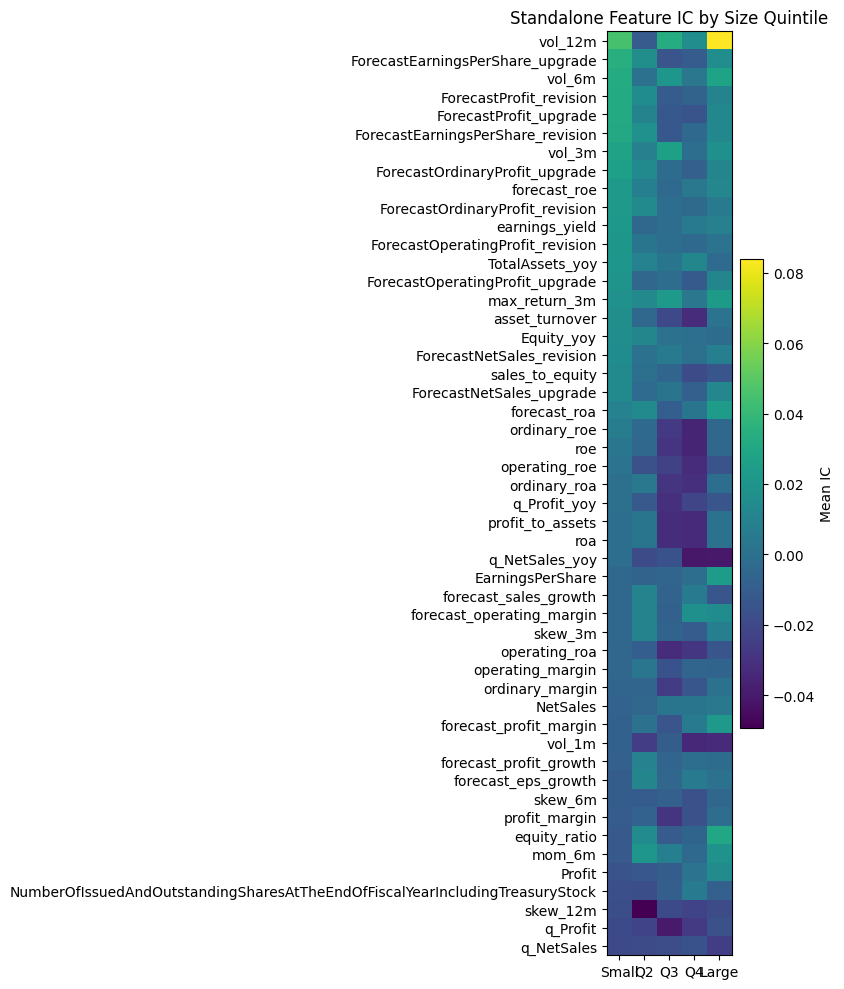

In [76]:
import matplotlib.pyplot as plt

plot_data = (
    pivot.drop(columns="Difference")
         .sort_values("Small", ascending=False)
         .head(50)
)

plt.figure(figsize=(8,10))

plt.imshow(
    plot_data.values,
    aspect="auto"
)

plt.xticks(
    range(5),
    plot_data.columns
)

plt.yticks(
    range(len(plot_data)),
    plot_data.index
)

plt.colorbar(label="Mean IC")

plt.title("Standalone Feature IC by Size Quintile")

plt.tight_layout()

plt.show()